In [8]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

## Vanila-FNO

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

input shape - different u_0: (250, 1000)
output shape - different u_t: (250, 1000, 1000)
x shape: (1000,)
t_domain shape: (1000,)


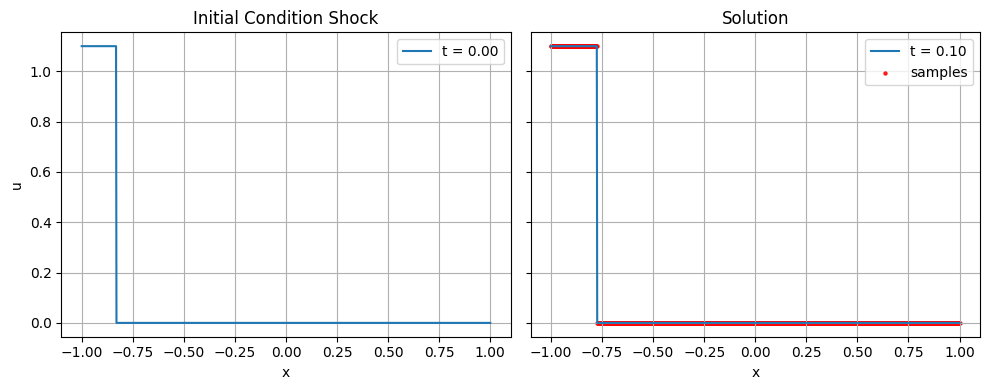

In [9]:
def plot_solution(x, u_0, u_t, t_plot,dt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    ax1.plot(x, u_0, label="t = 0.00")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u")
    ax1.set_title("Initial Condition Shock")
    ax1.legend()
    ax1.grid()

    ax2.plot(x, u_t[int(t_plot/dt)], label="t = %.2f" % t_plot)
    ax2.scatter(x, u_t[int(t_plot/dt)], color='red', s=5, label="samples", alpha=0.8)
    ax2.set_xlabel("x")
    ax2.set_title("Solution")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

N_data = 250
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity.npz", allow_pickle=True)
discon_data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity.npz")

input_data, output_data = data["X"], data["Y"]
discon_x_data = discon_data["Y"].astype(np.float32)
x = data["x"]
t_domain = data["t"]

print("input shape - different u_0:", input_data.shape)
print("output shape - different u_t:", output_data.shape)
print("x shape:", x.shape)
print("t_domain shape:", t_domain.shape)
plot_solution(x, input_data[189, :], output_data[189, :], t_domain[200], dt=t_domain[1]-t_domain[0])

#### Step 2: Training

In [10]:
points_per_step = 2025  # sampled (x,t) points per batch
network_width = 64  # width of the FNO network

In [11]:
# ---------------------------
# 1) Prepare data
# ---------------------------
X, Y = input_data.astype(np.float32), output_data.astype(np.float32)    # (N, Nx), (N, Nt, Nx)
N, Nx, Nt = X.shape[0], x.shape[0], t_domain.shape[0]

### Subsample a smaller (t, x) gird for training (to speed up training and reduce memory)
nx_sub, nt_sub = int(np.sqrt(points_per_step)), int(np.sqrt(points_per_step))
x_idx, t_idx = np.linspace(0, Nx - 1, nx_sub, dtype=int), np.linspace(0, Nt - 1, nt_sub, dtype=int)

X = X[:, x_idx]                  # (N, nx_sub)
Y = Y[:, t_idx][:, :, x_idx]     # (N, nt_sub, nx_sub)

# Update grid variables to subsampled regular grid
x_sub, t_sub = x[x_idx].astype(np.float32), t_domain[t_idx].astype(np.float32)
xx, tt = np.meshgrid(x_sub, t_sub, indexing="xy")

# Build FNO input: [u0(x), x, t] -> (N, 3, nt_sub, nx_sub)
u0 = np.repeat(X[:, None, None, :], nt_sub, axis=2)                     # (N, 1, nt_sub, Nx_sub)
xx_b = np.broadcast_to(xx[None, None, :, :], (N, 1, nt_sub, nx_sub))    # (N, 1, nt_sub, nx_sub)
tt_b = np.broadcast_to(tt[None, None, :, :], (N, 1, nt_sub, nx_sub))    # (N, 1, nt_sub, nx_sub)
X_in = np.concatenate([u0, xx_b, tt_b], axis=1)                         # (N, 3, nt_sub, nx_sub)
Y_out = Y[:, None, :, :]                                                # (N, 1, nt_sub, nx_sub)

# train/val split
rng = np.random.default_rng(42)
all_idx = np.arange(N)
rng.shuffle(all_idx)
n_train = int(0.1 * N)
train_idx, val_idx = all_idx[:n_train], all_idx[n_train:]

train_ds = TensorDataset(torch.from_numpy(X_in[train_idx]), torch.from_numpy(Y_out[train_idx]))
val_ds   = TensorDataset(torch.from_numpy(X_in[val_idx]), torch.from_numpy(Y_out[val_idx]))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

# ---------------------------
# 2) Define 2D FNO
# ---------------------------
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        b, c, h, w = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(b, self.out_channels, h, w // 2 + 1, dtype=torch.cfloat, device=x.device)

        m1 = min(self.modes1, h)
        m2 = min(self.modes2, w // 2 + 1)

        out_ft[:, :, :m1, :m2] = self.compl_mul2d(x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])

        return torch.fft.irfft2(out_ft, s=(h, w))

class FNO2d(nn.Module):
    def __init__(self, in_channels=3, width=64, modes1=12, modes2=12):
        super().__init__()
        self.fc0 = nn.Linear(in_channels, width)

        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (B, 3, Nt, Nx)
        x = x.permute(0, 2, 3, 1)      # (B, Nt, Nx, 3)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)      # (B, width, Nt, Nx)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))
        x = F.gelu(self.conv3(x) + self.w3(x))

        x = x.permute(0, 2, 3, 1)      # (B, Nt, Nx, width)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x.permute(0, 3, 1, 2)   # (B, 1, Nt, Nx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FNO2d(in_channels=3, width=network_width, modes1=12, modes2=12).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 300
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            running_val += loss_fn(pred, yb).item() * xb.size(0)

    val_loss = running_val / max(len(val_loader.dataset), 1)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_loss:.6e} | val_loss={val_loss:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses,
}
torch.save(checkpoint, f"checkpoints/vanilla_fno_checkpoint_sample_{points_per_step}_width_{network_width}.pt")
print(f"Saved: vanilla_fno_checkpoint_sample_{points_per_step}_width_{network_width}.pt")

Epoch    1/300 | train_loss=8.045979e-01 | val_loss=7.641284e-01
Epoch   10/300 | train_loss=7.182611e-01 | val_loss=6.749617e-01
Epoch   20/300 | train_loss=1.478340e-01 | val_loss=1.226182e-01
Epoch   30/300 | train_loss=8.581207e-02 | val_loss=8.777546e-02
Epoch   40/300 | train_loss=6.189295e-02 | val_loss=6.571389e-02
Epoch   50/300 | train_loss=4.598185e-02 | val_loss=5.025878e-02
Epoch   60/300 | train_loss=3.392759e-02 | val_loss=3.926054e-02
Epoch   70/300 | train_loss=2.750154e-02 | val_loss=3.353053e-02
Epoch   80/300 | train_loss=2.418421e-02 | val_loss=3.060701e-02
Epoch   90/300 | train_loss=2.228981e-02 | val_loss=2.808558e-02
Epoch  100/300 | train_loss=2.049970e-02 | val_loss=2.671655e-02
Epoch  110/300 | train_loss=1.938602e-02 | val_loss=2.549102e-02
Epoch  120/300 | train_loss=1.838010e-02 | val_loss=2.448311e-02
Epoch  130/300 | train_loss=1.747203e-02 | val_loss=2.358201e-02
Epoch  140/300 | train_loss=1.678618e-02 | val_loss=2.311407e-02
Epoch  150/300 | train_lo

#### Step 3: Test performance & Tracking

In [15]:
def error_analysis_all_t(pred, true, xx, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx])) for idx in range(xx.shape[0])])

    left_bound = np.maximum(disc_idx - window_size, 0)
    right_bound = np.minimum(xx.shape[1], disc_idx + window_size + 1)

    # l1_loss near discontinuity
    abs_err_near_dis = np.array([abs_err[i, left_bound[i]:right_bound[i]] for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis)

    return l1_loss, l1_loss_near_discon, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    # Build FNO input for one sample: [u0(x), x, t] -> (1, 3, Nt, Nx)
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    xx_b, tt_b = np.broadcast_to(xx[None, None, :, :], (1, 1, Nt, Nx)), np.broadcast_to(tt[None, None, :, :], (1, 1, Nt, Nx))  # (1, 1, Nt, Nx)

    l1_loss_all, l1_loss_near_discon_all = [], []

    for sample_id in range(input_data_test.shape[0]):
        X_sample, Y_sample = input_data_test[sample_id, :].astype(np.float32), output_data_test[sample_id, :].astype(np.float32)
        u0 = np.repeat(X_sample[None, None, None, :], Nt, axis=2)              # (1, 1, Nt, Nx)
        X_in = np.concatenate([u0, xx_b, tt_b], axis=1)                        # (1, 3, Nt, Nx)
        
        # Predict
        with torch.no_grad():
            X_in = torch.from_numpy(X_in).to(device)
            pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()            # (Nt, Nx)

        # Error analysis
        l1_loss, l1_loss_near_discon, _, _ = error_analysis_all_t(pred_field, Y_sample, xx, true_discon=discon_x_data_test[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data, output_data, x, t_domain, discon_x_data, sample_id):
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])

    # Pick one validation sample (original dataset index)
    X_sample, Y_sample = input_data[sample_id, :].astype(np.float32), output_data[sample_id, :].astype(np.float32)

    # Build FNO input for one sample: [u0(x), x, t] -> (1, 3, Nt, Nx)
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    xx_b, tt_b = np.broadcast_to(xx[None, None, :, :], (1, 1, Nt, Nx)), np.broadcast_to(tt[None, None, :, :], (1, 1, Nt, Nx))  # (1, 1, Nt, Nx)
    u0 = np.repeat(X_sample[None, None, None, :], Nt, axis=2)              # (1, 1, Nt, Nx)
    X_in = np.concatenate([u0, xx_b, tt_b], axis=1)                        # (1, 3, Nt, Nx)

    # Predict
    with torch.no_grad():
        X_in = torch.from_numpy(X_in).to(device)
        pred_field = model(X_in).squeeze(0).squeeze(0).cpu().numpy()            # (Nt, Nx)

    # Error analysis
    discon_x_data = discon_x_data[sample_id]
    _, _, left_bound, right_bound = error_analysis_all_t(pred_field, Y_sample, xx, true_discon=discon_x_data, window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    # Plot at a chosen time
    t_plot = 0.07
    t_plot_idx = int(t_plot / (t_domain[1] - t_domain[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(x, X_sample, color="blue", label="u0")
    axes[0].set_title("Input function u0(x)")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x, pred_field[t_plot_idx], color="red", label="FNO pred")
    axes[1].plot(x, Y_sample[t_plot_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x[left_bound[t_plot_idx]], color='green', alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x[right_bound[t_plot_idx]], color='green', alpha=0.5)
    axes[1].set_title(f"t = {t_domain[t_plot_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

In [16]:
N_data = 20
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity_test.npz", allow_pickle=True)
discon_data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity_test.npz")

input_data_test, output_data_test = data["X"], data["Y"]
discon_x_data_test = discon_data["Y"].astype(np.float32)
x_test = data["x"]
t_domain_test = data["t"]

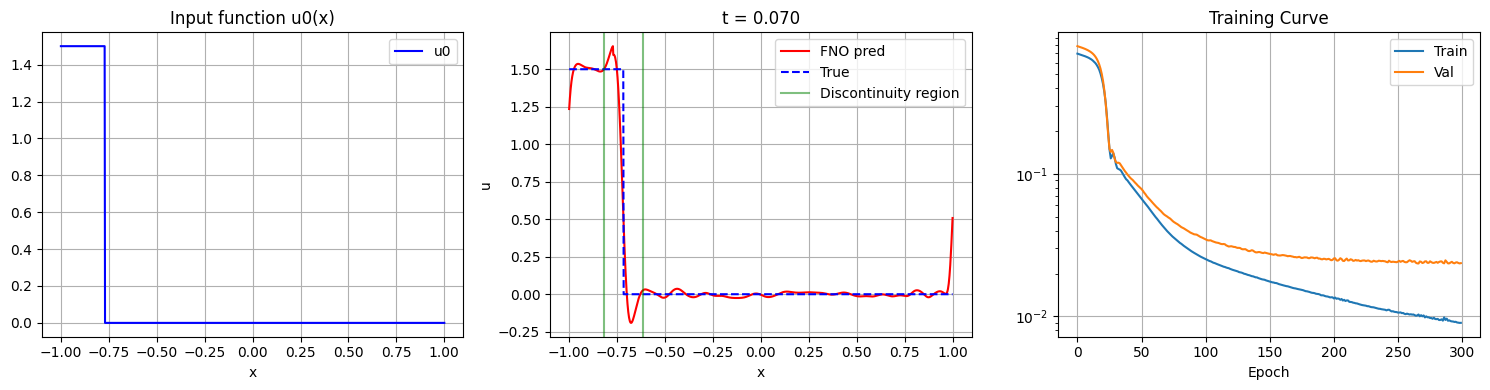

Total parameters: 4,743,937, trainable parameters: 4,743,937
L1 Loss (all points): 0.060, std: 0.035
L1 Loss (near discontinuity): 0.279, std: 0.110


In [17]:
# Load the trained Vanilla-FNO checkpoint
checkpoint = torch.load(f"checkpoints/vanilla_fno_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=int(0.05 * Nx)) # 5% of total points on each side of the discontinuity
show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id=1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")